# Exploratory data analysis

This notebook examines data integrity, panel coverage, missingness, target
heterogeneity, marginal distributions, short-lag dynamics, elementary signal
and train/test drift. Its purpose is to convert empirical observations into
explicit validation and modelling constraints.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import wasserstein_distance

sns.set_theme(style="whitegrid")
ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data import ChallengeDataLoader

train = ChallengeDataLoader.load_train_df()
test = ChallengeDataLoader.load_X_test()
X_train = train.drop(columns=["target", "target_binarized"])

RETURNS = [f"RET_{lag}" for lag in range(1, 21)]
VOLUMES = [f"SIGNED_VOLUME_{lag}" for lag in range(1, 21)]
RAW_FEATURES = RETURNS + VOLUMES + ["MEDIAN_DAILY_TURNOVER"]


def temporal_summaries(frame):
    # Create descriptive summaries from the supplied 20-lag history.
    return pd.DataFrame(
        {
            "recent_return_mean": frame[["RET_1", "RET_2", "RET_3"]].mean(axis=1),
            "medium_return_mean": frame[[f"RET_{lag}" for lag in range(1, 11)]].mean(axis=1),
            "older_return_mean": frame[[f"RET_{lag}" for lag in range(11, 21)]].mean(axis=1),
            "recent_minus_older": (
                frame[["RET_1", "RET_2", "RET_3"]].mean(axis=1)
                - frame[[f"RET_{lag}" for lag in range(11, 21)]].mean(axis=1)
            ),
            "short_return_volatility": frame[[f"RET_{lag}" for lag in range(1, 6)]].std(axis=1),
            "one_step_reversal": (
                frame["RET_1"]
                - frame[["RET_2", "RET_3", "RET_4", "RET_5"]].mean(axis=1)
            ),
            "positive_return_share": (frame[RETURNS] > 0).mean(axis=1),
        },
        index=frame.index,
    )


train_temporal = temporal_summaries(train)
test_temporal = temporal_summaries(test)

## 1. Data integrity and schema

In [2]:
train_hash = pd.util.hash_pandas_object(X_train, index=False)
test_hash = pd.util.hash_pandas_object(test, index=False)

integrity = pd.Series(
    {
        "train rows": len(train),
        "test rows": len(test),
        "train columns including targets": train.shape[1],
        "test feature columns": test.shape[1],
        "train index is unique": train.index.is_unique,
        "test index is unique": test.index.is_unique,
        "target index matches feature index": train.index.equals(X_train.index),
        "feature schema matches": set(X_train.columns) == set(test.columns),
        "duplicated train feature rows": int(X_train.duplicated().sum()),
        "duplicated test feature rows": int(test.duplicated().sum()),
        "exact feature rows shared across train and test": int(
            len(set(train_hash.unique()) & set(test_hash.unique()))
        ),
        "infinite numeric values in train": int(
            np.isinf(train.select_dtypes(include=np.number)).sum().sum()
        ),
        "constant train feature columns": int(
            (X_train.nunique(dropna=False) <= 1).sum()
        ),
    },
    name="value",
)
integrity.to_frame()

,value
train rows,527073
test rows,31870
train columns including targets,46
test feature columns,44
train index is unique,True
test index is unique,True
target index matches feature index,True
feature schema matches,True
duplicated train feature rows,0
duplicated test feature rows,0


In [3]:
def support_row(column):
    train_values = set(train[column].dropna().unique())
    test_values = set(test[column].dropna().unique())
    return {
        "column": column,
        "train levels": len(train_values),
        "test levels": len(test_values),
        "shared levels": len(train_values & test_values),
        "train-only levels": len(train_values - test_values),
        "test-only levels": len(test_values - train_values),
    }


support = pd.DataFrame([support_row(column) for column in ["TS", "ALLOCATION", "GROUP"]])
support

,column,train levels,test levels,shared levels,train-only levels,test-only levels
0,TS,2522,120,0,2522,120
1,ALLOCATION,278,278,278,0,0
2,GROUP,4,4,4,0,0


The feature schema is shared by train and test, while the support of identifiers
must be checked explicitly. Test-only allocation levels, if present, require an
encoder that handles previously unseen categories.

## 2. Panel structure and coverage

In [4]:
panel_overview = pd.DataFrame(
    {
        "rows": [len(train), len(test)],
        "dates": [train["TS"].nunique(), test["TS"].nunique()],
        "allocations": [train["ALLOCATION"].nunique(), test["ALLOCATION"].nunique()],
        "groups": [train["GROUP"].nunique(), test["GROUP"].nunique()],
        "median rows per date": [
            train.groupby("TS").size().median(),
            test.groupby("TS").size().median(),
        ],
        "median dates per allocation": [
            train.groupby("ALLOCATION")["TS"].nunique().median(),
            test.groupby("ALLOCATION")["TS"].nunique().median(),
        ],
    },
    index=["train", "test"],
)
panel_overview

,rows,dates,allocations,groups,median rows per date,median dates per allocation
train,527073,2522,278,4,276.0,1864.0
test,31870,120,278,4,278.0,114.0


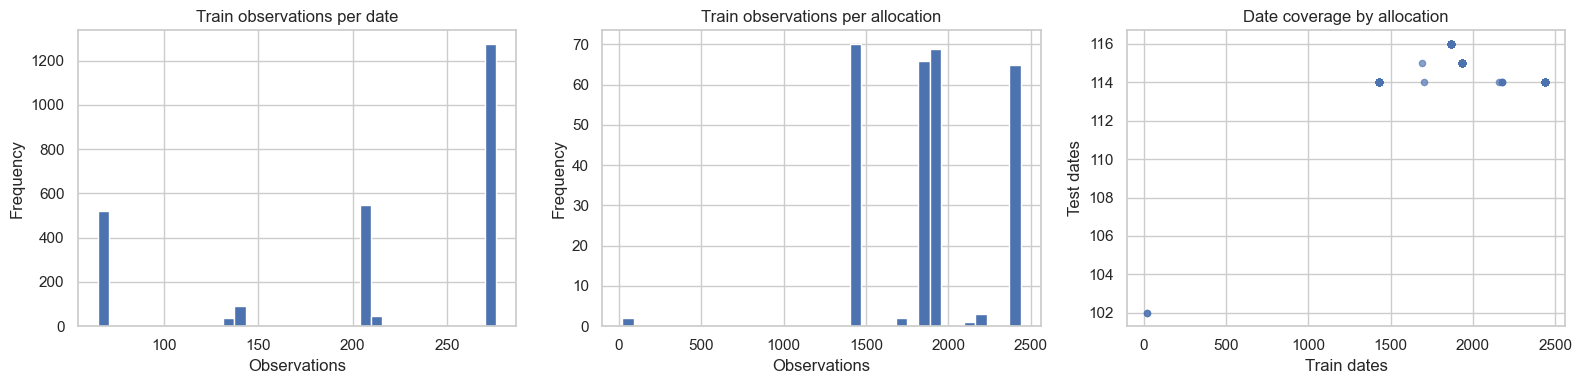

,count,mean,std,min,25%,50%,75%,max
train,278.0,1895.946043,388.833385,19.0,1431.0,1864.0,1931.0,2439.0
test,278.0,114.640288,1.354267,102.0,114.0,114.0,115.0,116.0


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
train.groupby("TS").size().plot.hist(bins=35, ax=axes[0])
axes[0].set_title("Train observations per date")
axes[0].set_xlabel("Observations")

train.groupby("ALLOCATION").size().plot.hist(bins=35, ax=axes[1])
axes[1].set_title("Train observations per allocation")
axes[1].set_xlabel("Observations")

coverage = pd.concat(
    [
        train.groupby("ALLOCATION")["TS"].nunique().rename("train"),
        test.groupby("ALLOCATION")["TS"].nunique().rename("test"),
    ],
    axis=1,
).fillna(0)
coverage.plot.scatter(x="train", y="test", alpha=0.65, ax=axes[2])
axes[2].set_title("Date coverage by allocation")
axes[2].set_xlabel("Train dates")
axes[2].set_ylabel("Test dates")
plt.tight_layout()
plt.show()

coverage.describe().T

The dataset is an unbalanced panel: coverage varies across dates and
allocations. Complete dates must remain together during validation, and
allocation effects must be regularised rather than estimated independently
without shrinkage.

## 3. Missing-value structure

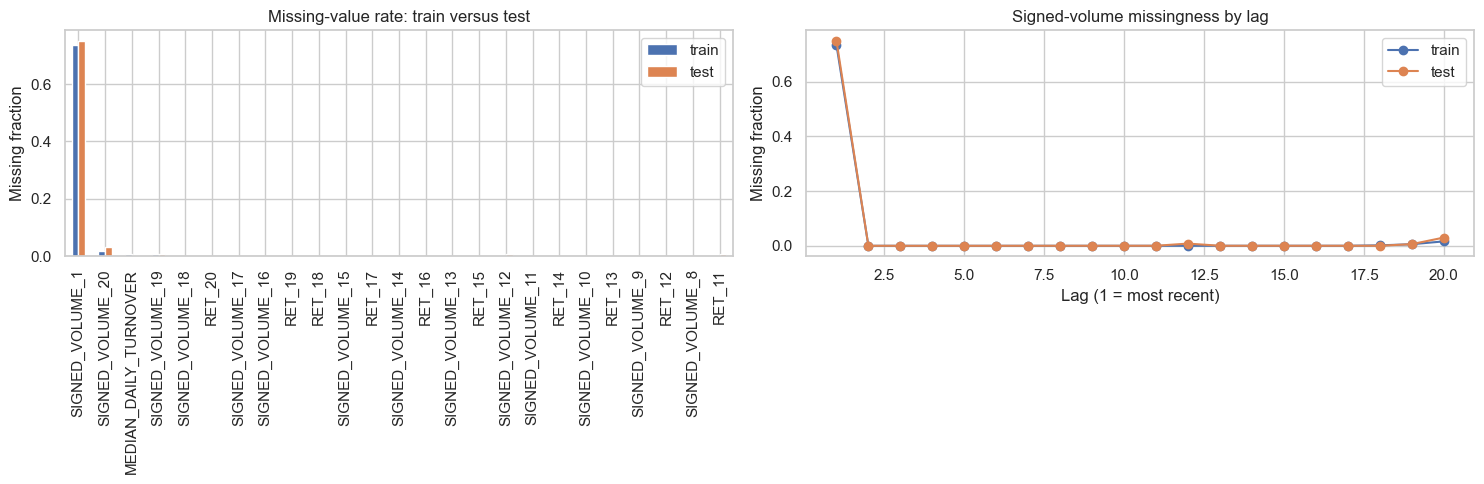

,train,test,absolute difference
SIGNED_VOLUME_1,0.735204,0.750361,0.015157
SIGNED_VOLUME_20,0.016123,0.029965,0.013842
SIGNED_VOLUME_12,0.000034,0.008095,0.008061
RET_11,0.000008,0.008033,0.008025
MEDIAN_DAILY_TURNOVER,0.006902,0.004675,0.002227
SIGNED_VOLUME_18,0.001630,0.000126,0.001504
SIGNED_VOLUME_19,0.005696,0.005993,0.000297
SIGNED_VOLUME_9,0.000011,0.000126,0.000114
RET_12,0.000011,0.000126,0.000114
SIGNED_VOLUME_10,0.000017,0.000126,0.000108


In [6]:
missing = pd.concat(
    [X_train.isna().mean().rename("train"), test.isna().mean().rename("test")],
    axis=1,
)
missing["absolute difference"] = (missing["test"] - missing["train"]).abs()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
missing.sort_values("train", ascending=False).head(25)[["train", "test"]].plot.bar(ax=axes[0])
axes[0].set_title("Missing-value rate: train versus test")
axes[0].set_ylabel("Missing fraction")
axes[0].set_xlabel("")

volume_missing = pd.DataFrame(
    {
        "lag": range(1, 21),
        "train": [train[f"SIGNED_VOLUME_{lag}"].isna().mean() for lag in range(1, 21)],
        "test": [test[f"SIGNED_VOLUME_{lag}"].isna().mean() for lag in range(1, 21)],
    }
)
volume_missing.plot(x="lag", y=["train", "test"], marker="o", ax=axes[1])
axes[1].set_title("Signed-volume missingness by lag")
axes[1].set_xlabel("Lag (1 = most recent)")
axes[1].set_ylabel("Missing fraction")
plt.tight_layout()
plt.show()

missing.sort_values("absolute difference", ascending=False).head(10)

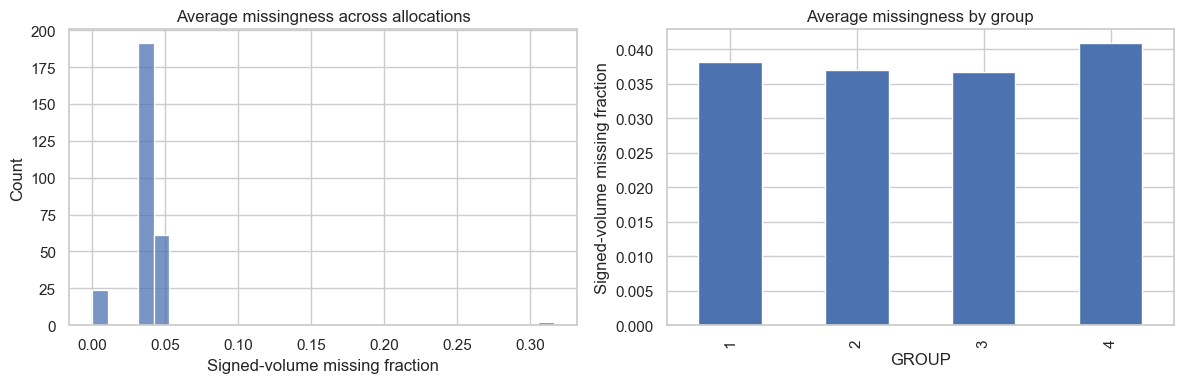

,rows,mean_missing_share,positive_rate
missingness bucket,,,
none,137587,0.000000,0.517411
up to 50%,389474,0.051348,0.503577
more than 50%,12,0.625000,0.333333


In [7]:
signed_volume_missing_share = train[VOLUMES].isna().mean(axis=1)
missing_bucket = pd.cut(
    signed_volume_missing_share,
    bins=[-0.01, 0.0, 0.5, 0.999, 1.0],
    labels=["none", "up to 50%", "more than 50%", "all"],
)
missing_target_summary = (
    pd.DataFrame(
        {
            "missingness bucket": missing_bucket,
            "missing share": signed_volume_missing_share,
            "positive target": train["target_binarized"],
        }
    )
    .groupby("missingness bucket", observed=True)
    .agg(
        rows=("positive target", "size"),
        mean_missing_share=("missing share", "mean"),
        positive_rate=("positive target", "mean"),
    )
)

allocation_missing = signed_volume_missing_share.groupby(train["ALLOCATION"]).mean()
group_missing = signed_volume_missing_share.groupby(train["GROUP"]).mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(allocation_missing, bins=30, ax=axes[0])
axes[0].set_title("Average missingness across allocations")
axes[0].set_xlabel("Signed-volume missing fraction")
group_missing.sort_index().plot.bar(ax=axes[1])
axes[1].set_title("Average missingness by group")
axes[1].set_ylabel("Signed-volume missing fraction")
plt.tight_layout()
plt.show()

missing_target_summary

Signed-volume missingness is structured across lags and entities rather than
uniform. Its association with the target is descriptive only; missing-value
handling and any missingness indicators must be fitted or evaluated inside the
validation procedure.

## 4. Target balance and panel heterogeneity

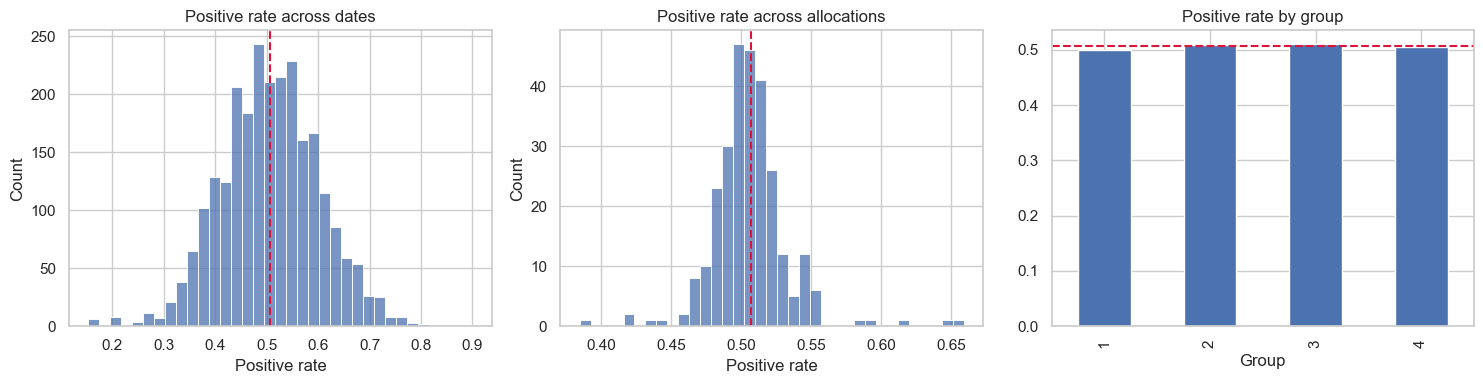

,TS,ALLOCATION,GROUP
count,2522.000000,278.000000,4.000000
mean,0.506849,0.505933,0.506557
std,0.095972,0.027389,0.004415
min,0.153846,0.384657,0.500519
10%,0.387681,0.480130,0.502165
25%,0.442029,0.492491,0.504634
50%,0.507246,0.504920,0.507894
75%,0.568841,0.516365,0.509817
90%,0.630248,0.533243,0.509878
max,0.900000,0.658877,0.509919


In [8]:
overall_positive_rate = train["target_binarized"].mean()
target_by = {
    level: train.groupby(level)["target_binarized"].mean()
    for level in ["TS", "ALLOCATION", "GROUP"]
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, level, title in zip(
    axes,
    ["TS", "ALLOCATION", "GROUP"],
    ["Positive rate across dates", "Positive rate across allocations", "Positive rate by group"],
):
    values = target_by[level]
    if level == "GROUP":
        values.sort_index().plot.bar(ax=ax)
    else:
        sns.histplot(values, bins=35, ax=ax)
    ax.axvline(overall_positive_rate, color="crimson", linestyle="--") if level != "GROUP" else ax.axhline(overall_positive_rate, color="crimson", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Positive rate" if level != "GROUP" else "Group")
plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        level: values.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
        for level, values in target_by.items()
    }
)

Target prevalence varies across dates and allocations, so rows are not
exchangeable independent observations.

This EDA deliberately does not estimate standard errors. A separate notebook
based on simulated panel data will show the econometric implications of date
effects, allocation effects, serial dependence and unbalanced coverage. It will
compare naive, one-way clustered, two-way clustered and bootstrap procedures
before an inferential method is selected for model comparisons.

## 5. Marginal feature distributions

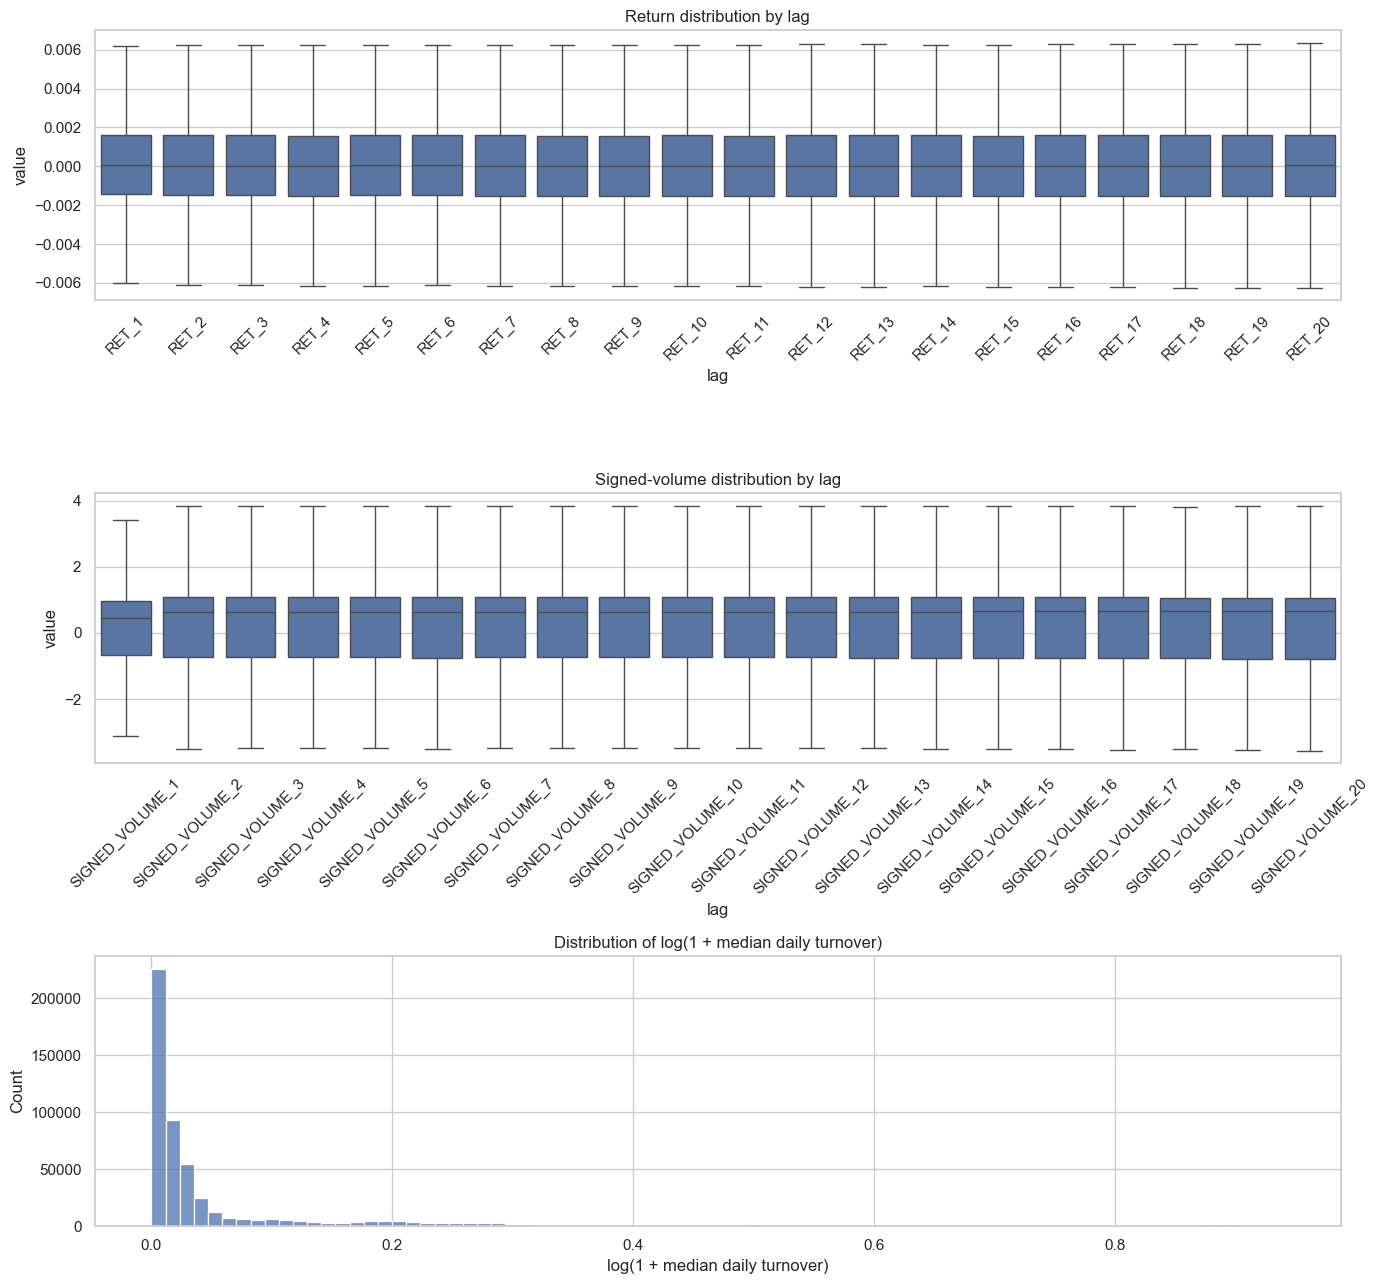

In [9]:
plot_sample = train.sample(n=min(100_000, len(train)), random_state=0)
fig, axes = plt.subplots(3, 1, figsize=(14, 13))
sns.boxplot(
    data=plot_sample[RETURNS].melt(var_name="lag", value_name="value"),
    x="lag", y="value", order=RETURNS, showfliers=False, ax=axes[0],
)
axes[0].set_title("Return distribution by lag")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=plot_sample[VOLUMES].melt(var_name="lag", value_name="value"),
    x="lag", y="value", order=VOLUMES, showfliers=False, ax=axes[1],
)
axes[1].set_title("Signed-volume distribution by lag")
axes[1].tick_params(axis="x", rotation=45)

sns.histplot(np.log1p(train["MEDIAN_DAILY_TURNOVER"]), bins=80, ax=axes[2])
axes[2].set_title("Distribution of log(1 + median daily turnover)")
axes[2].set_xlabel("log(1 + median daily turnover)")
plt.tight_layout()
plt.show()

In [10]:
selected_features = ["RET_1", "RET_4", "RET_7", "SIGNED_VOLUME_1", "SIGNED_VOLUME_10", "MEDIAN_DAILY_TURNOVER"]
distribution_summary = pd.DataFrame(
    {
        "missing rate": train[selected_features].isna().mean(),
        "1% quantile": train[selected_features].quantile(0.01),
        "median": train[selected_features].median(),
        "99% quantile": train[selected_features].quantile(0.99),
        "standard deviation": train[selected_features].std(),
        "skewness": train[selected_features].skew(),
    }
)
distribution_summary

,missing rate,1% quantile,median,99% quantile,standard deviation,skewness
RET_1,0.000000,-0.008180,0.000062,0.008245,0.003041,0.384282
RET_4,0.000000,-0.008331,0.000035,0.008226,0.003051,0.235472
RET_7,0.000000,-0.008308,0.000031,0.008181,0.003048,0.230025
SIGNED_VOLUME_1,0.735204,-3.778100,0.470273,3.692340,1.495215,-3.897994
SIGNED_VOLUME_10,0.000017,-3.986119,0.635481,3.805160,1.591820,-3.671384
MEDIAN_DAILY_TURNOVER,0.006902,0.000045,0.015935,1.405543,0.236489,4.322450


## 6. Short-lag behaviour across allocations

`RET_1` is treated as the most recent supplied return and `RET_20` as the
oldest. This ordering supports analysis of the short history contained in each
row. By contrast, the labels in `TS` are not parsed or assumed to form a usable
chronological sequence.

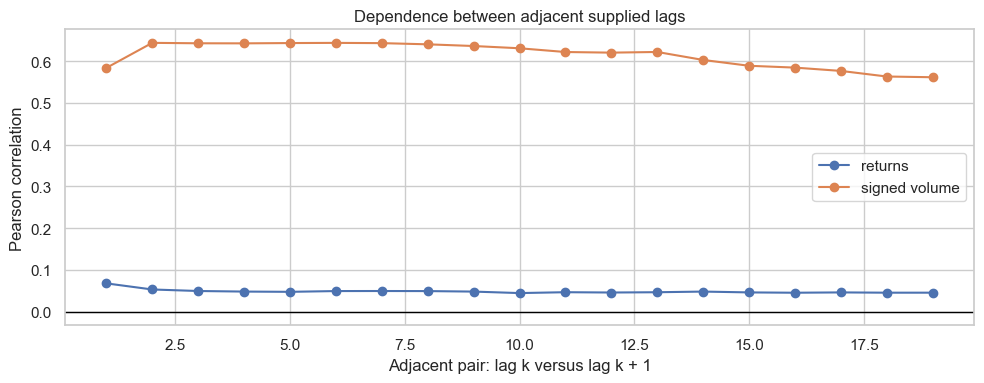

,recent lag,returns,signed volume
0,1,0.067915,0.583877
1,2,0.053297,0.643918
2,3,0.049640,0.642892
3,4,0.048263,0.642725
4,5,0.047652,0.643426
5,6,0.049493,0.643862
6,7,0.049609,0.643252
7,8,0.049431,0.640408
8,9,0.048226,0.636342
9,10,0.044674,0.630958


In [11]:
adjacent_dependence = pd.DataFrame(
    {
        "recent lag": range(1, 20),
        "returns": [train[f"RET_{lag}"].corr(train[f"RET_{lag + 1}"]) for lag in range(1, 20)],
        "signed volume": [
            train[f"SIGNED_VOLUME_{lag}"].corr(train[f"SIGNED_VOLUME_{lag + 1}"])
            for lag in range(1, 20)
        ],
    }
)

fig, ax = plt.subplots(figsize=(10, 4))
adjacent_dependence.plot(x="recent lag", y=["returns", "signed volume"], marker="o", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Dependence between adjacent supplied lags")
ax.set_xlabel("Adjacent pair: lag k versus lag k + 1")
ax.set_ylabel("Pearson correlation")
plt.tight_layout()
plt.show()
adjacent_dependence

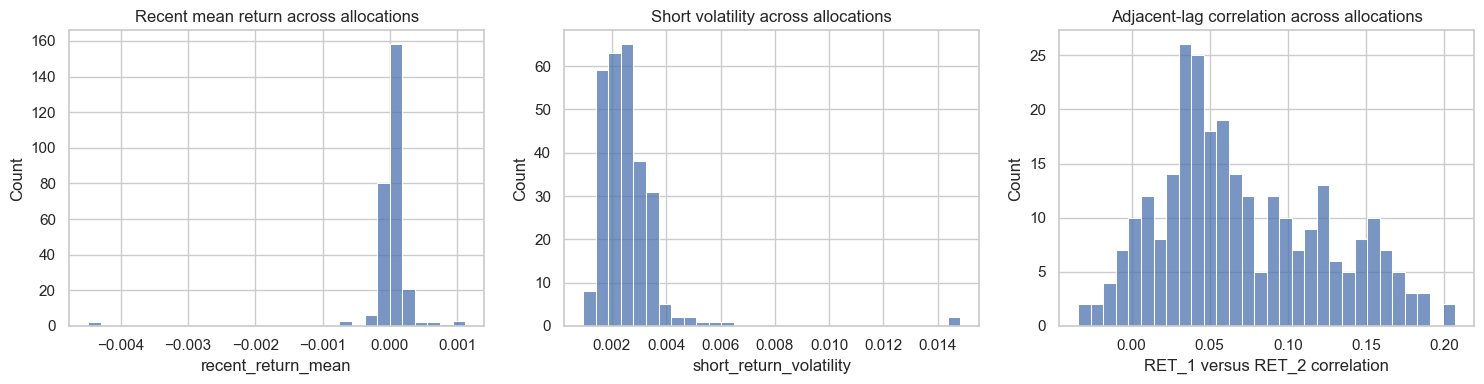

,count,mean,std,min,25%,50%,75%,max
recent_return_mean,278.0,0.000018,0.000425,-0.004488,-0.000024,0.000038,0.000096,0.001119
short_return_volatility,278.0,0.002576,0.001307,0.000936,0.001910,0.002396,0.002986,0.014832
RET_1 versus RET_2 correlation,278.0,0.071161,0.052875,-0.034270,0.033233,0.057714,0.112532,0.207165


In [12]:
allocation_temporal = train_temporal.groupby(train["ALLOCATION"]).mean()
allocation_adjacent_correlation = pd.Series(
    {
        allocation: group["RET_1"].corr(group["RET_2"])
        for allocation, group in train.groupby("ALLOCATION")
    },
    name="RET_1 versus RET_2 correlation",
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(allocation_temporal["recent_return_mean"], bins=30, ax=axes[0])
axes[0].set_title("Recent mean return across allocations")
sns.histplot(allocation_temporal["short_return_volatility"], bins=30, ax=axes[1])
axes[1].set_title("Short volatility across allocations")
sns.histplot(allocation_adjacent_correlation.dropna(), bins=30, ax=axes[2])
axes[2].set_title("Adjacent-lag correlation across allocations")
plt.tight_layout()
plt.show()

pd.concat(
    [
        allocation_temporal[["recent_return_mean", "short_return_volatility"]].describe().T,
        allocation_adjacent_correlation.describe().to_frame().T,
    ]
)

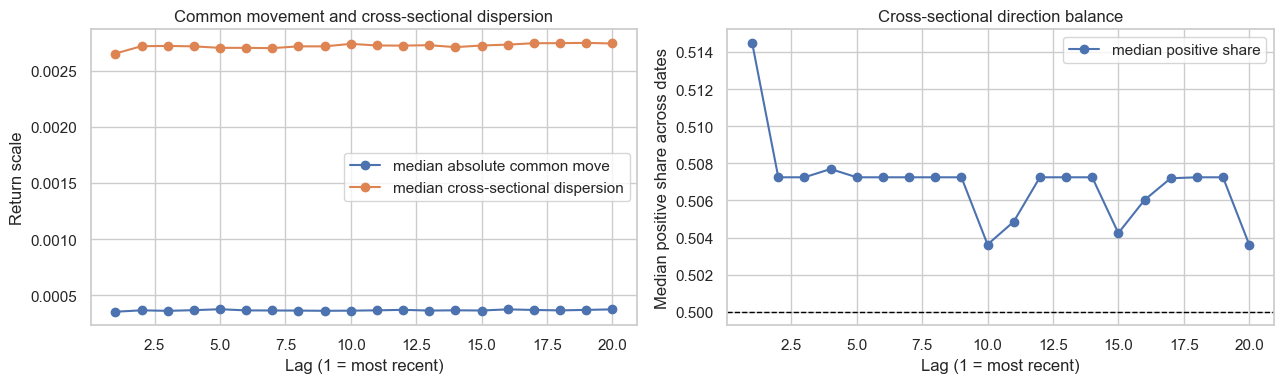

,lag,median absolute common move,median cross-sectional dispersion,median positive share
0,1,0.000353,0.002652,0.514493
1,2,0.000365,0.002717,0.507246
2,3,0.000361,0.002719,0.507246
3,4,0.000367,0.002716,0.507692
4,5,0.000375,0.002702,0.507246
5,6,0.000365,0.002703,0.507246
6,7,0.000364,0.002700,0.507246
7,8,0.000363,0.002716,0.507246
8,9,0.000361,0.002716,0.507246
9,10,0.000363,0.002738,0.503623


In [13]:
date_location = train.groupby("TS")[RETURNS].median()
date_dispersion = train.groupby("TS")[RETURNS].std()
cross_sectional_profile = pd.DataFrame(
    {
        "lag": range(1, 21),
        "median absolute common move": [date_location[f"RET_{lag}"].abs().median() for lag in range(1, 21)],
        "median cross-sectional dispersion": [date_dispersion[f"RET_{lag}"].median() for lag in range(1, 21)],
        "median positive share": [
            train.assign(positive=train[f"RET_{lag}"] > 0).groupby("TS")["positive"].mean().median()
            for lag in range(1, 21)
        ],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cross_sectional_profile.plot(
    x="lag",
    y=["median absolute common move", "median cross-sectional dispersion"],
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Common movement and cross-sectional dispersion")
axes[0].set_xlabel("Lag (1 = most recent)")
axes[0].set_ylabel("Return scale")
cross_sectional_profile.plot(x="lag", y="median positive share", marker="o", ax=axes[1])
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Cross-sectional direction balance")
axes[1].set_xlabel("Lag (1 = most recent)")
axes[1].set_ylabel("Median positive share across dates")
plt.tight_layout()
plt.show()

cross_sectional_profile

The supplied histories contain both allocation-specific variation and a common
cross-sectional component. Short-history summaries may therefore be useful,
but their value must be tested inside grouped validation rather than inferred
from marginal plots alone.

## 7. Univariate and conditional signal

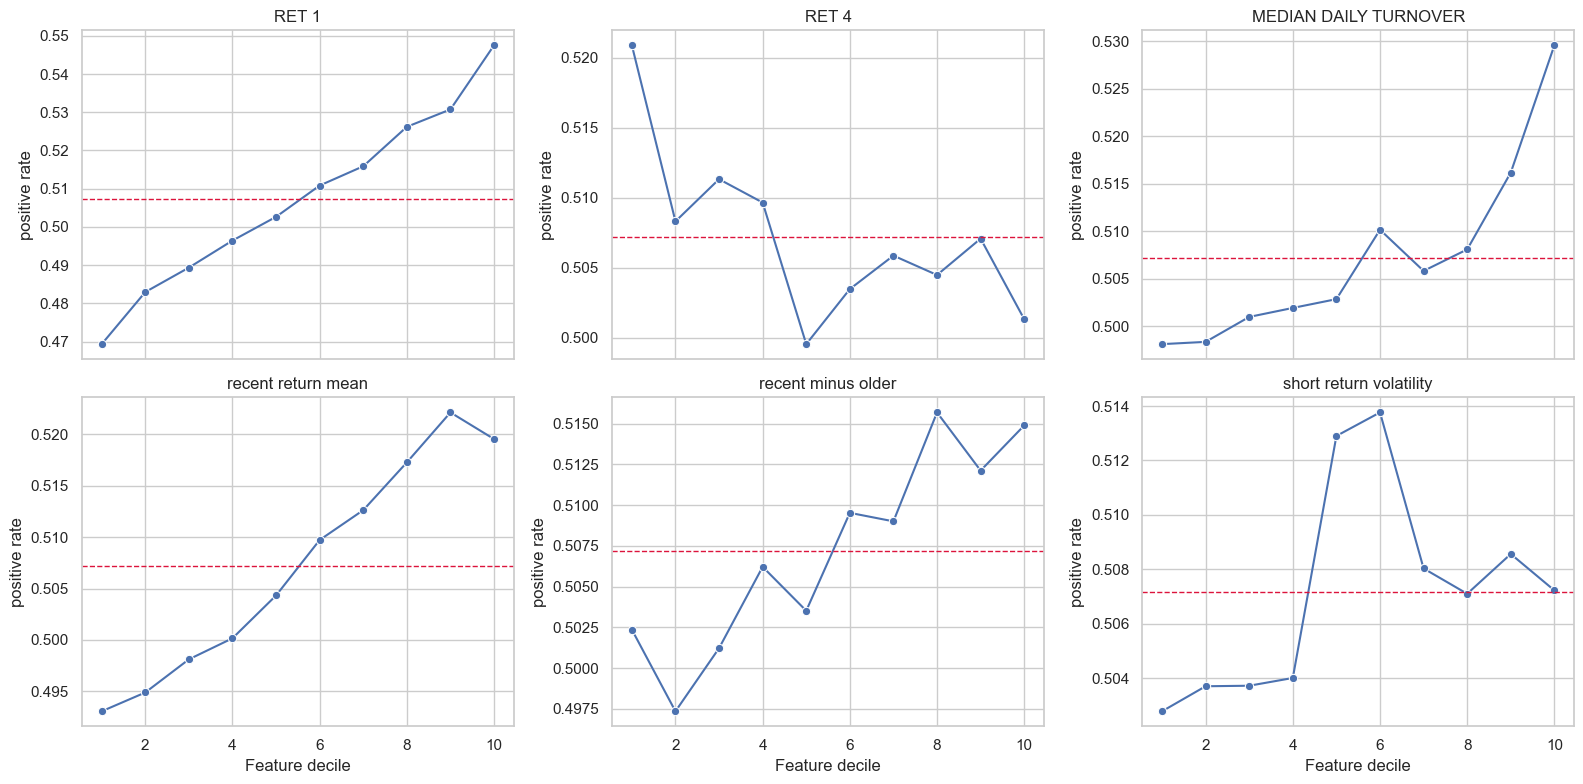

,decile,rows,positive rate,feature
0,1,52708,0.469322,RET_1
1,2,52707,0.482953,RET_1
2,3,52707,0.489347,RET_1
3,4,52707,0.496424,RET_1
4,5,52708,0.502637,RET_1
5,6,52707,0.510824,RET_1
6,7,52707,0.515871,RET_1
7,8,52707,0.526192,RET_1
8,9,52707,0.530745,RET_1
9,10,52708,0.547526,RET_1


In [14]:
signal_frame = pd.concat(
    [
        train[["RET_1", "RET_4", "RET_7", "MEDIAN_DAILY_TURNOVER", "target_binarized"]],
        train_temporal,
    ],
    axis=1,
)
signal_features = [
    "RET_1",
    "RET_4",
    "MEDIAN_DAILY_TURNOVER",
    "recent_return_mean",
    "recent_minus_older",
    "short_return_volatility",
]

decile_rows = []
for feature in signal_features:
    valid = signal_frame[[feature, "target_binarized"]].dropna()
    decile = pd.qcut(valid[feature].rank(method="first"), q=10, labels=range(1, 11))
    decile = decile.rename("decile")
    rates = valid.groupby(decile, observed=True)["target_binarized"].agg(["size", "mean"])
    rates = rates.rename(columns={"size": "rows", "mean": "positive rate"}).reset_index()
    rates["feature"] = feature
    decile_rows.append(rates)
decile_signal = pd.concat(decile_rows, ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
for ax, feature in zip(axes.flat, signal_features):
    subset = decile_signal[decile_signal["feature"] == feature]
    sns.lineplot(data=subset, x="decile", y="positive rate", marker="o", ax=ax)
    ax.axhline(overall_positive_rate, color="crimson", linestyle="--", linewidth=1)
    ax.set_title(feature.replace("_", " "))
    ax.set_xlabel("Feature decile")
plt.tight_layout()
plt.show()

decile_signal.head(12)

In [15]:
rules = pd.DataFrame(index=train.index)
rules["sign of RET_1"] = (train["RET_1"].fillna(0) > 0).astype(int)
date_median_ret1 = train.groupby("TS")["RET_1"].transform("median")
rules["date-neutralised RET_1"] = (train["RET_1"].fillna(0) > date_median_ret1.fillna(0)).astype(int)
rules["sign of recent mean"] = (train_temporal["recent_return_mean"].fillna(0) > 0).astype(int)

rule_rows = []
for name in rules:
    correct = rules[name].eq(train["target_binarized"])
    accuracy_by_date = correct.groupby(train["TS"]).mean()
    rule_rows.append(
        {
            "rule": name,
            "overall accuracy": correct.mean(),
            "mean date accuracy": accuracy_by_date.mean(),
            "dates above 50% accuracy": (accuracy_by_date > 0.5).mean(),
            "prediction positive rate": rules[name].mean(),
        }
    )
pd.DataFrame(rule_rows).set_index("rule")

,overall accuracy,mean date accuracy,dates above 50% accuracy,prediction positive rate
rule,,,,
sign of RET_1,0.518924,0.523091,0.589611,0.511722
date-neutralised RET_1,0.517103,0.520588,0.590801,0.499534
sign of recent mean,0.509379,0.509310,0.530928,0.512737


`RET_1` is the strongest elementary signal, but all univariate relationships
remain weak. Conditional plots guide hypotheses; they do not replace
out-of-fold model comparisons.

## 8. Train/test drift

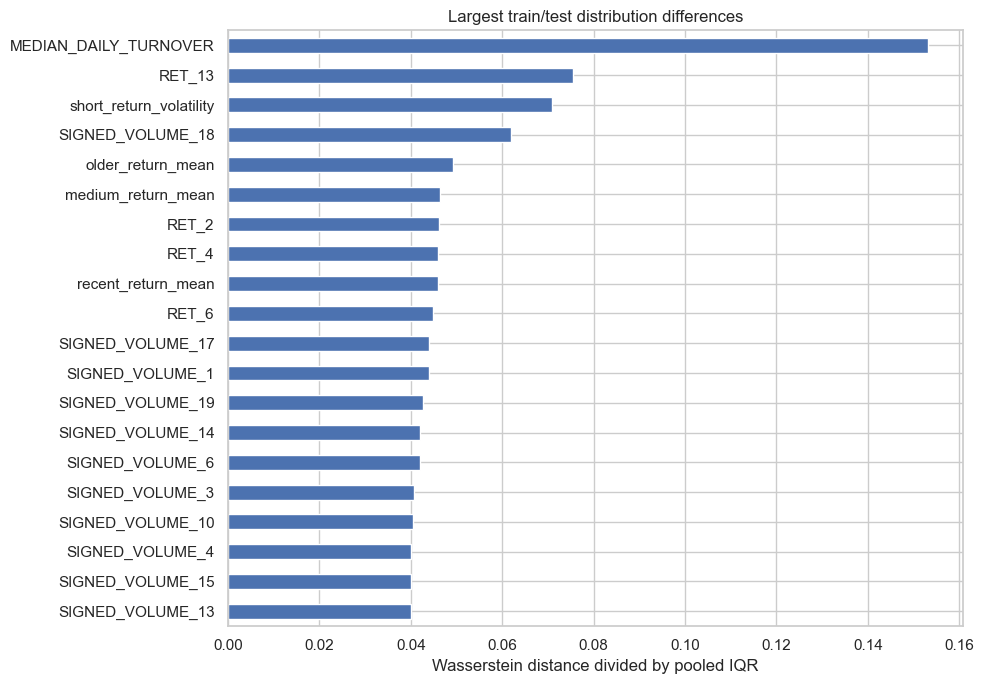

,feature,normalised Wasserstein distance,normalised median shift,missing-rate difference
40,MEDIAN_DAILY_TURNOVER,0.153223,0.023004,0.002227
12,RET_13,0.075436,0.048223,0.000108
45,short_return_volatility,0.070930,0.085281,0.000000
37,SIGNED_VOLUME_18,0.061949,0.009604,0.001504
43,older_return_mean,0.049127,0.040528,0.000055
42,medium_return_mean,0.046299,0.017116,0.000000
1,RET_2,0.046191,0.000923,0.000000
3,RET_4,0.046022,0.023101,0.000000
41,recent_return_mean,0.045899,0.003253,0.000000
5,RET_6,0.044844,0.025023,0.000000


In [16]:
drift_train = pd.concat([X_train[RAW_FEATURES], train_temporal], axis=1)
drift_test = pd.concat([test[RAW_FEATURES], test_temporal], axis=1)

drift_rows = []
for feature in drift_train.columns:
    train_values = drift_train[feature].dropna().to_numpy()
    test_values = drift_test[feature].dropna().to_numpy()
    pooled = np.concatenate([train_values, test_values])
    scale = np.quantile(pooled, 0.75) - np.quantile(pooled, 0.25)
    scale = scale if scale > 0 else np.std(pooled)
    scale = scale if scale > 0 else 1.0
    drift_rows.append(
        {
            "feature": feature,
            "normalised Wasserstein distance": wasserstein_distance(train_values, test_values) / scale,
            "normalised median shift": abs(np.median(test_values) - np.median(train_values)) / scale,
            "missing-rate difference": abs(drift_test[feature].isna().mean() - drift_train[feature].isna().mean()),
        }
    )
drift = pd.DataFrame(drift_rows).sort_values("normalised Wasserstein distance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
drift.head(20).sort_values("normalised Wasserstein distance").plot.barh(
    x="feature", y="normalised Wasserstein distance", legend=False, ax=ax
)
ax.set_title("Largest train/test distribution differences")
ax.set_xlabel("Wasserstein distance divided by pooled IQR")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

drift.head(15)

In [17]:
def total_variation(column):
    train_frequency = train[column].value_counts(normalize=True)
    test_frequency = test[column].value_counts(normalize=True)
    aligned = pd.concat([train_frequency, test_frequency], axis=1).fillna(0)
    return 0.5 * (aligned.iloc[:, 0] - aligned.iloc[:, 1]).abs().sum()


categorical_drift = pd.DataFrame(
    {
        "total variation distance": [total_variation("GROUP"), total_variation("ALLOCATION")],
        "test levels unseen in train": [
            len(set(test["GROUP"]) - set(train["GROUP"])),
            len(set(test["ALLOCATION"]) - set(train["ALLOCATION"])),
        ],
    },
    index=["GROUP", "ALLOCATION"],
)
categorical_drift

,total variation distance,test levels unseen in train
GROUP,0.073488,0
ALLOCATION,0.074243,0


## 9. Validation implications and conclusions

| Empirical observation | Consequence |
|---|---|
| Unbalanced date-allocation panel | Keep complete `TS` groups together during validation. |
| Dependence across dates and allocations | Select the inferential procedure in a separate panel-simulation notebook. |
| Structured signed-volume missingness | Fit imputation and any missingness features inside each fold. |
| Short-lag dependence | Evaluate temporal summaries without reconstructing or ordering `TS`. |
| Common and allocation-specific movements | Compare raw and cross-sectionally neutralised signals. |
| Weak individual signal | Prefer regularised baselines before adding model complexity. |
| Limited but non-zero distribution differences | Track marginal, missingness and short-history drift separately. |
| Categorical support differences | Use encoders that safely handle unknown levels. |

The EDA establishes the validation constraints and candidate signal families.
Performance claims and uncertainty estimates belong to the dedicated modelling
and econometric notebooks.